# Crop Yield Prediction — Random Forest Regression

This notebook trains a model that predicts crop yield (tons/hectare) using soil, weather-related, and farming input data (fertilizer, pesticide, area, season, state, crop type, year).

Dataset: Indian government crop production data, narrowed down to 5 commonly grown crops — Rice, Maize, Moong (Green Gram), Urad, and Groundnut.

The final trained model is saved at the end so it can be loaded into a Streamlit app for anyone to use.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

## 1. Load the dataset

Loading the crop data from Drive and narrowing it down to the 5 crops I picked for this project.

In [ ]:
df = pd.read_excel('/content/drive/MyDrive/crop_yield 1.xlsx')

# keeping only the 5 crops I decided to focus on
df = df[df.crop.isin(["Rice", "Maize", "Moong(Green Gram)", "Urad", "Groundnut"])].reset_index(drop=True)

df.head()

,crop,year,season,state,area,production,fertilizer,pesticide,yield
0,Maize,1997,Kharif,Assam,19216.0,14721,1.828787e+06,5956.96,0.615652
1,Rice,1997,Autumn,Assam,607358.0,398311,5.780226e+07,188280.98,0.780870
2,Rice,1997,Summer,Assam,174974.0,209623,1.665228e+07,54241.94,1.060435
3,Rice,1997,Winter,Assam,1743321.0,1647296,1.659119e+08,540429.51,0.941304
4,Groundnut,1997,Kharif,Karnataka,847666.0,525562,8.067237e+07,262776.46,0.709412


## 2. Feature engineering

Raw fertilizer/pesticide totals aren't fair to compare across farms of different sizes, so converted them to a per-hectare basis. I also simplified the year column.

In [ ]:
# fertilizer/pesticide use per hectare, instead of raw totals
df['fertilizer_per_area'] = df['fertilizer'] / df['area']
df['pesticide_per_area'] = df['pesticide'] / df['area']

# years since the dataset started (1997), easier for the model to work with than raw year
df['years_since_start'] = df['year'] - df['year'].min()

## 3. Encode categorical columns

crop, season, and state are text categories with no natural order, so I used one-hot encoding instead of label encoding. This avoids the model assuming a false ranking between categories.

In [ ]:
# keeping a copy with original crop/season/state columns, useful later for the app dropdowns
df_before_encoding = df.copy()

df = pd.get_dummies(df, columns=['crop', 'season', 'state'], drop_first=True)

# dropping raw columns I've already replaced with better versions
# (production is dropped too - it's basically the answer in disguise, keeping it would be data leakage)
df = df.drop(columns=['fertilizer', 'pesticide', 'year', 'production'])

df.head()

,area,yield,crop_Maize,crop_Moong(Green Gram),crop_Rice,crop_Urad,season_Kharif,season_Rabi,season_Summer,season_Whole Year,...,state_Odisha,state_Puducherry,state_Punjab,state_Sikkim,state_Tamil Nadu,state_Telangana,state_Tripura,state_Uttar Pradesh,state_Uttarakhand,state_West Bengal
0,19216.0,0.615652,True,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,607358.0,0.780870,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,174974.0,1.060435,False,False,True,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,1743321.0,0.941304,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,847666.0,0.709412,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## 4. Train/test split

In [ ]:
X = df.drop(columns=['yield'])
y = df['yield']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])
print("Total features:", X_train.shape[1])

Training rows: 3489
Testing rows: 873
Total features: 39


## 5. Train the Random Forest model

Went with Random Forest because yield doesn't behave linearly with things like fertilizer (helps up to a point, then flattens out) — a tree-based model handles that kind of pattern much better than a straight line would.

In [ ]:
rf_model = RandomForestRegressor(n_estimators=200, max_depth=None, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2: {r2:.4f}")

MAE: 0.2669
RMSE: 0.5511
R2: 0.8353


## 6. Feature importance

Quick look at which features the model relied on most.

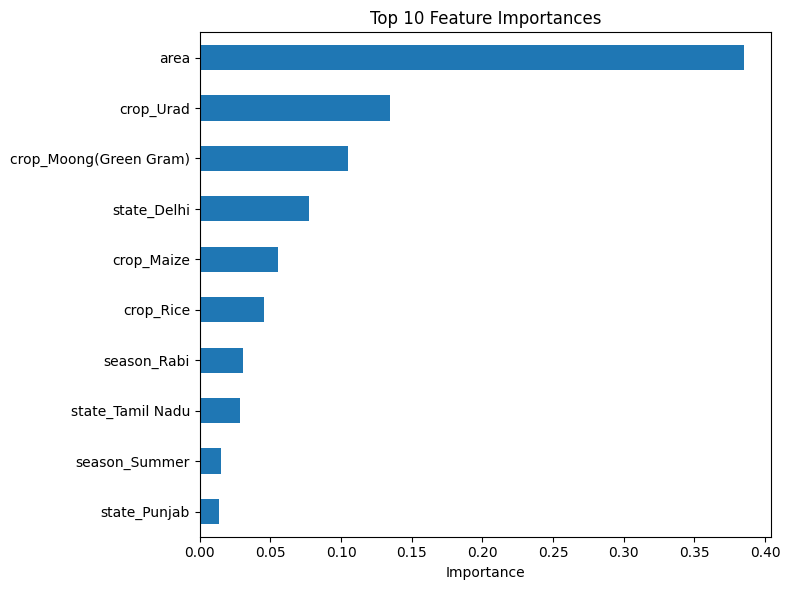

In [ ]:
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8,6))
importances.head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances")
plt.tight_layout()
plt.show()

## 7. Predicted vs Actual yield

A quick visual check — the closer the points sit to the red line, the better the prediction.

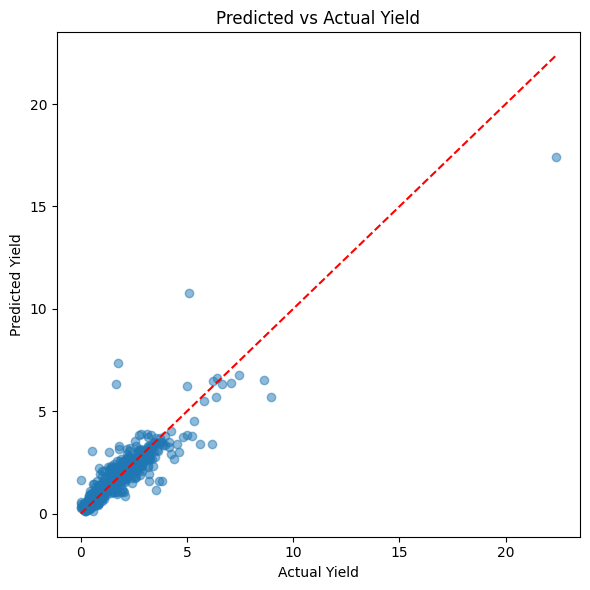

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Predicted vs Actual Yield")
plt.tight_layout()
plt.show()

## 8. Save the model for deployment

Saving the trained model and the exact list of feature columns, so the Streamlit app knows what input format to expect.

In [ ]:
joblib.dump(rf_model, '/content/drive/MyDrive/crop_yield_rf_model.pkl')
joblib.dump(list(X_train.columns), '/content/drive/MyDrive/crop_yield_model_columns.pkl')

print("Model and column list saved.")

Model and column list saved.
